## 02. Scratchpad

### 1. File handling via Data.py 

In [1]:
import Data
import matplotlib.pyplot as plt

In [2]:
path = '../data/tatoeba_1/eng-pol_1.tsv'
df = Data.upload_tsv(path=path, col_drop=[0, 2])
df.head(3)

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.


In [3]:
df_tok = Data.tokenize_data(df=df, src_col='eng_text', tgt_col='pol_text')
df_tok.head(3)

,eng_text,pol_text,eng_len,pol_len
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8


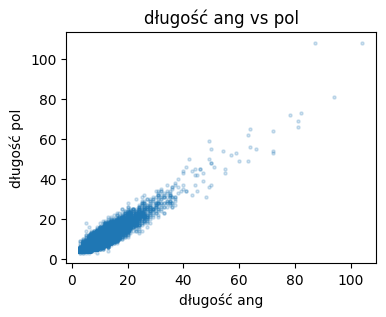

In [4]:
plt.figure(figsize=(4, 3))
plt.scatter(df_tok['eng_len'], df_tok['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

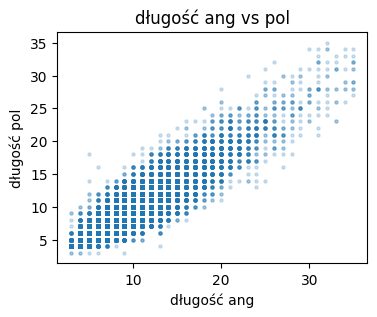

In [5]:
df_trim = Data.trim_data(df=df_tok, src_len='eng_len', tgt_len='pol_len', thres=35)
plt.figure(figsize=(4, 3))
plt.scatter(df_trim['eng_len'], df_trim['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [6]:
df_ids, eng_vocab, pol_vocab = Data.tokens_to_id(df=df_trim, src_col='eng_text', tgt_col='pol_text')
df_ids.head(3)

,eng_text,pol_text,eng_len,pol_len,src_ids,tgt_ids
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5,"[158, 270, 122, 3, 2]","[3, 3408, 68, 4, 2]"
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6,"[5, 20, 6, 54, 6, 325, 3, 2]","[3, 89, 104, 294, 4, 2]"
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8,"[3448, 11, 1746, 94, 3, 2]","[3, 4379, 26, 75, 1345, 115, 4, 2]"


In [7]:
df_data = df_ids[['src_ids', 'tgt_ids']]
df_data.head(3)

,src_ids,tgt_ids
0,"[158, 270, 122, 3, 2]","[3, 3408, 68, 4, 2]"
1,"[5, 20, 6, 54, 6, 325, 3, 2]","[3, 89, 104, 294, 4, 2]"
2,"[3448, 11, 1746, 94, 3, 2]","[3, 4379, 26, 75, 1345, 115, 4, 2]"


In [8]:
df_train, df_val = Data.shuffle_split(df=df_data, tr_per=0.8)
print(df_train.shape, df_val.shape)
df_train.head(3)

(67056, 2) (16765, 2)


,src_ids,tgt_ids
0,"[9, 195, 1, 3, 2]","[3, 88, 2716, 8, 1, 4, 2]"
1,"[100, 20, 8, 152, 42, 21, 149, 3, 2]","[3, 938, 13, 151, 204, 4, 2]"
2,"[80, 7, 320, 383, 8, 3150, 473, 6, 9, 10, 2]","[3, 1, 145, 88, 5943, 13, 1415, 7, 2]"


In [9]:
train_data = Data.EngPolDataset(df_train, 'src_ids', 'tgt_ids')
val_data = Data.EngPolDataset(df_val, 'src_ids', 'tgt_ids')

### 2. Training Transformers Model

In [10]:
import Model
import Trainer
import Predict

In [14]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(len(eng_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(len(pol_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [16]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test 1")

In [20]:
# trainer.fit(model, train_data, val_data, 5, '../checkpoints/checkpoint.pt')